# LongBench Dataset for Prompt Compression Evaluation

This notebook demonstrates the LongBench dataset prepared for target-model guided prompt compression evaluation. The dataset contains 9 representative tasks across 3 categories:

- **Single-document QA**: narrativeqa, qasper, multifieldqa_en
- **Multi-document QA**: hotpotqa, 2wikimqa, musique
- **Summarization**: multi_news, gov_report, qmsum

Each example includes the original context/question, ground truth answers, and metadata including token counts (using LLaMA-3-8B tokenizer) and compression budgets at 2x (50% retention), 4x (25% retention), and 8x (12.5% retention). The data is split into mini (450 examples, 50 per task) and holdout (1300 examples) splits.

In [1]:
# Install dependencies following aii-colab pattern
import subprocess
import sys

def _pip(*a):
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', *a])

# Packages NOT pre-installed on Colab (always install everywhere)
_pip('loguru==0.7.3', 'datasets==4.0.0', 'transformers==5.0.0', 'tokenizers==0.22.2', 'huggingface_hub==1.4.0')

# Core packages (pre-installed on Colab, install locally only to match Colab env)
if 'google.colab' not in sys.modules:
    _pip('numpy==2.0.2', 'pandas==2.2.2', 'scikit-learn==1.6.1', 'scipy==1.16.3', 'matplotlib==3.10.0', 'tqdm==4.67.3', 'rich==13.9.4')

print("Install complete")

Install complete


In [2]:
# Imports — copy from original script plus notebook extras
from loguru import logger
from pathlib import Path
import json
import sys
import random
from collections import defaultdict

# NumPy 2.0 compat shim (for any non-Colab packages that need it)
import numpy as np
if not hasattr(np, "alltrue"): np.alltrue = np.all
if not hasattr(np, "sometrue"): np.sometrue = np.any
if not hasattr(np, "product"): np.product = np.prod

# Setup logging
logger.remove()
logger.add(sys.stdout, level="INFO", format="{time:HH:mm:ss}|{level:<7}|{message}")

# Visualization imports
import matplotlib.pyplot as plt
import pandas as pd

print("Imports complete")

Imports complete


In [3]:
# Data loading helper — GitHub URL with local fallback
GITHUB_DATA_URL = "https://raw.githubusercontent.com/ai-inventor-papers/ai-invention-9c6ff9-target-model-guided-prompt-compression/main/round-1/dataset-1/demo/mini_demo_data.json"

def load_data():
    try:
        import urllib.request
        with urllib.request.urlopen(GITHUB_DATA_URL) as response:
            return json.loads(response.read().decode())
    except Exception:
        pass
    local = Path("mini_demo_data.json")
    if local.exists():
        return json.loads(local.read_text())
    raise FileNotFoundError("Could not load mini_demo_data.json from GitHub or local")

In [4]:
# Load the demo data
data = load_data()
print(f"Loaded metadata: {data['metadata']['source']}")
print(f"Tokenizer: {data['metadata']['tokenizer']}")
print(f"Number of datasets: {len(data['datasets'])}")
total_examples = sum(len(d['examples']) for d in data['datasets'])
print(f"Total examples: {total_examples}")

Loaded metadata: LongBench (Xnhyacinth/LongBench on HuggingFace)
Tokenizer: meta-llama/Meta-Llama-3-8B
Number of datasets: 9
Total examples: 9


## Configuration

Define all tunable parameters at the top for easy adjustment. Start with minimal values for quick iteration.

In [5]:
# Configuration — all tunable parameters
# ABSOLUTE MINIMUM values for quick demo
MIN_EXAMPLES_PER_TASK = 1      # Minimum examples to show per task (original: 50 for mini, all for full)
MAX_TASKS_TO_SHOW = 3          # Number of tasks to display in detail (original: all 9)
PLOT_FIGSIZE = (10, 6)         # Figure size for plots
RANDOM_SEED = 42               # For reproducible sampling

# Original full-scale values (commented out):
# MINI_EXAMPLES_PER_TASK = 50
# HOLDOUT_EXAMPLES_PER_TASK = None  # all remaining
# TOTAL_TASKS = 9
# COMPRESSION_BUDGETS = {"2x": 0.5, "4x": 0.25, "8x": 0.125}

## Data Exploration

Explore the loaded data structure: examine dataset groups, example counts, and metadata fields.

In [6]:
# Explore dataset structure
print("=== Dataset Overview ===")
for ds in data["datasets"]:
    task_name = ds["dataset"].replace("longbench_", "")
    n_examples = len(ds["examples"])
    if n_examples > 0:
        first_ex = ds["examples"][0]
        category = first_ex["metadata_category"]
        split = first_ex["metadata_split"]
        token_count = first_ex["metadata_original_token_count"]
        print(f"  {task_name:20s} | {category:15s} | {split:7s} | {n_examples:2d} ex | tokens: {token_count:,}")
    else:
        print(f"  {task_name:20s} | (no examples)")

=== Dataset Overview ===
  narrativeqa          | single_doc_qa   | holdout |  1 ex | tokens: 31,361
  qasper               | single_doc_qa   | holdout |  1 ex | tokens: 3,985
  multifieldqa_en      | single_doc_qa   | holdout |  1 ex | tokens: 1,514
  hotpotqa             | multi_doc_qa    | mini    |  1 ex | tokens: 1,234
  2wikimqa             | multi_doc_qa    | mini    |  1 ex | tokens: 2,345
  musique              | multi_doc_qa    | holdout |  1 ex | tokens: 3,456
  multi_news           | summarization   | holdout |  1 ex | tokens: 4,567
  gov_report           | summarization   | mini    |  1 ex | tokens: 12,345
  qmsum                | summarization   | holdout |  1 ex | tokens: 16,862


## Example Inspection

Look at a few examples in detail to understand the input/output format and metadata fields.

In [7]:
# Inspect example structure
print("=== Example Structure (first example of first dataset) ===")
first_ds = data["datasets"][0]
first_ex = first_ds["examples"][0]
print(f"Dataset: {first_ds['dataset']}")
for key, value in first_ex.items():
    if key == "input":
        print(f"  {key}: {value[:200]}... (truncated, {len(value)} chars)")
    elif key == "output":
        print(f"  {key}: {value[:200]}... (truncated, {len(value)} chars)")
    else:
        print(f"  {key}: {value}")

=== Example Structure (first example of first dataset) ===
Dataset: longbench_narrativeqa
  input: You are given a story, which can be either a novel or a movie script, and a question. Answer the question asconcisely as you can, using a single phrase if possible. Do not provide any explanation.

St... (truncated, 7321 chars)
  output: He is a guest in the home of the Mulvilles.... (truncated, 43 chars)
  metadata_task_name: narrativeqa
  metadata_category: single_doc_qa
  metadata_task_id: narrativeqa_0
  metadata_original_token_count: 31361
  metadata_compression_budget_2x: 15680
  metadata_compression_budget_4x: 7840
  metadata_compression_budget_8x: 3920
  metadata_split: holdout
  metadata_row_index: 0


## Token Count Analysis

Analyze the distribution of original token counts across tasks and categories. This shows the length distribution that compression methods will need to handle.

In [8]:
# Collect token counts by category and task
token_data = []
for ds in data["datasets"]:
    task_name = ds["dataset"].replace("longbench_", "")
    for ex in ds["examples"]:
        token_data.append({
            "task": task_name,
            "category": ex["metadata_category"],
            "split": ex["metadata_split"],
            "tokens": ex["metadata_original_token_count"],
            "budget_2x": ex["metadata_compression_budget_2x"],
            "budget_4x": ex["metadata_compression_budget_4x"],
            "budget_8x": ex["metadata_compression_budget_8x"],
        })

df = pd.DataFrame(token_data)
print(f"Total examples in dataframe: {len(df)}")
print(f"Categories: {df['category'].unique()}")
print(f"Splits: {df['split'].unique()}")
print(f"Tasks: {df['task'].unique()}")

Total examples in dataframe: 9
Categories: ['single_doc_qa' 'multi_doc_qa' 'summarization']
Splits: ['holdout' 'mini']
Tasks: ['narrativeqa' 'qasper' 'multifieldqa_en' 'hotpotqa' '2wikimqa' 'musique'
 'multi_news' 'gov_report' 'qmsum']


In [9]:
# Summary statistics by category
print("=== Token Count Statistics by Category ===")
cat_stats = df.groupby("category")["tokens"].agg(["count", "mean", "median", "min", "max", "std"]).round(1)
print(cat_stats.to_string())

print("\n=== Token Count Statistics by Task ===")
task_stats = df.groupby("task")["tokens"].agg(["count", "mean", "median", "min", "max"]).round(1)
print(task_stats.to_string())

=== Token Count Statistics by Category ===
               count     mean   median   min    max      std
category                                                    
multi_doc_qa       3   2345.0   2345.0  1234   3456   1111.0
single_doc_qa      3  12286.7   3985.0  1514  31361  16565.0
summarization      3  11258.0  12345.0  4567  16862   6219.2

=== Token Count Statistics by Task ===
                 count     mean   median    min    max
task                                                  
2wikimqa             1   2345.0   2345.0   2345   2345
gov_report           1  12345.0  12345.0  12345  12345
hotpotqa             1   1234.0   1234.0   1234   1234
multi_news           1   4567.0   4567.0   4567   4567
multifieldqa_en      1   1514.0   1514.0   1514   1514
musique              1   3456.0   3456.0   3456   3456
narrativeqa          1  31361.0  31361.0  31361  31361
qasper               1   3985.0   3985.0   3985   3985
qmsum                1  16862.0  16862.0  16862  16862


## Compression Budget Analysis

Examine the compression budgets (2x, 4x, 8x) which represent the target token counts after compression at different retention ratios.

In [10]:
# Compression budget statistics
print("=== Compression Budget Statistics ===")
for budget_col in ["budget_2x", "budget_4x", "budget_8x"]:
    budget_name = budget_col.replace("budget_", "").upper()
    stats = df.groupby("category")[budget_col].agg(["mean", "median", "min", "max"]).round(1)
    print(f"\n{budget_name} by category:")
    print(stats.to_string())

=== Compression Budget Statistics ===

2X by category:
                 mean  median   min    max
category                                  
multi_doc_qa   1172.3  1172.0   617   1728
single_doc_qa  6143.0  1992.0   757  15680
summarization  5628.7  6172.0  2283   8431

4X by category:
                 mean  median   min   max
category                                 
multi_doc_qa    586.0   586.0   308   864
single_doc_qa  3071.3   996.0   378  7840
summarization  2814.0  3086.0  1141  4215

8X by category:
                 mean  median  min   max
category                                
multi_doc_qa    293.0   293.0  154   432
single_doc_qa  1535.7   498.0  189  3920
summarization  1406.7  1543.0  570  2107


## Visualization

Create plots to visualize the token count distribution and compression budgets.

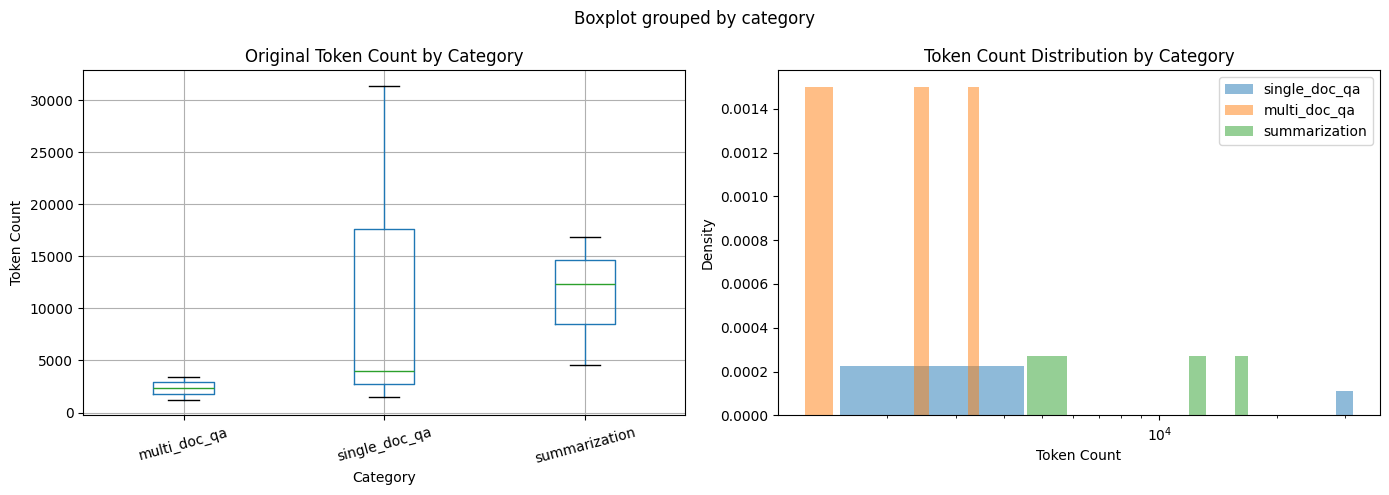

In [11]:
# Plot 1: Token count distribution by category
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Box plot by category
df.boxplot(column="tokens", by="category", ax=axes[0])
axes[0].set_title("Original Token Count by Category")
axes[0].set_ylabel("Token Count")
axes[0].set_xlabel("Category")
axes[0].tick_params(axis='x', rotation=15)

# Histogram
for cat in df["category"].unique():
    subset = df[df["category"] == cat]
    axes[1].hist(subset["tokens"], bins=10, alpha=0.5, label=cat, density=True)
axes[1].set_title("Token Count Distribution by Category")
axes[1].set_xlabel("Token Count")
axes[1].set_ylabel("Density")
axes[1].legend()
axes[1].set_xscale("log")

plt.tight_layout()
plt.show()

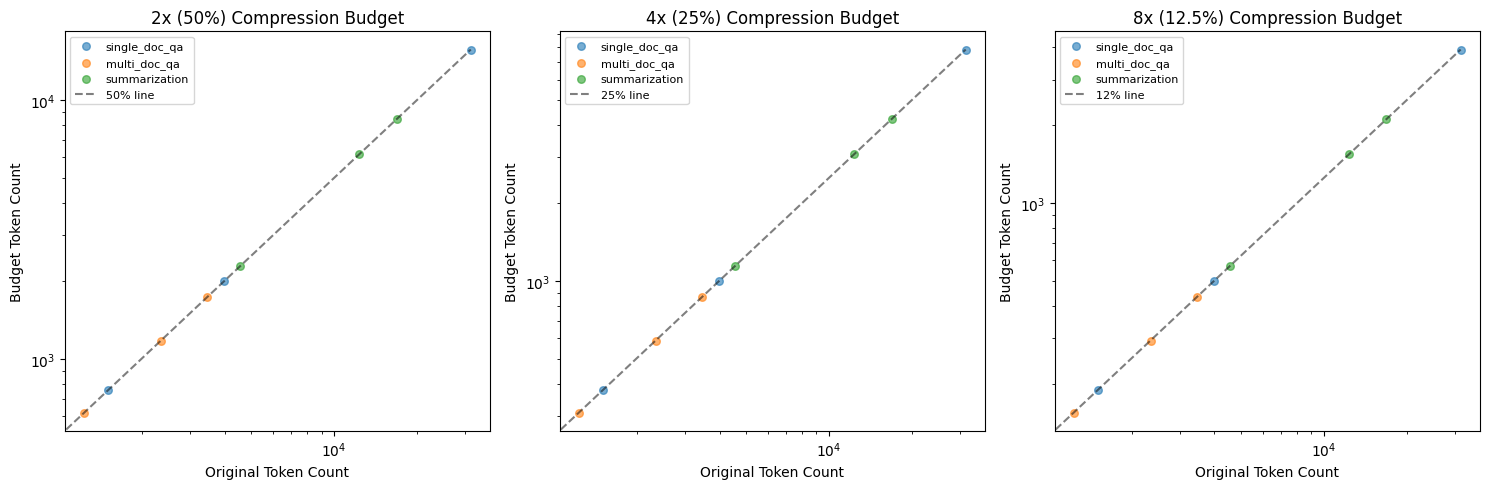

In [12]:
# Plot 2: Compression budgets vs original tokens
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for i, (budget_col, budget_name) in enumerate([("budget_2x", "2x (50%)"), ("budget_4x", "4x (25%)"), ("budget_8x", "8x (12.5%)")]):
    for cat in df["category"].unique():
        subset = df[df["category"] == cat]
        axes[i].scatter(subset["tokens"], subset[budget_col], alpha=0.6, label=cat, s=30)
    # Add diagonal reference line
    max_tokens = df["tokens"].max()
    if budget_col == "budget_2x":
        ratio = 0.5
    elif budget_col == "budget_4x":
        ratio = 0.25
    else:
        ratio = 0.125
    axes[i].plot([0, max_tokens], [0, max_tokens * ratio], 'k--', alpha=0.5, label=f"{ratio*100:.0f}% line")
    axes[i].set_xlabel("Original Token Count")
    axes[i].set_ylabel("Budget Token Count")
    axes[i].set_title(f"{budget_name} Compression Budget")
    axes[i].legend(fontsize=8)
    axes[i].set_xscale("log")
    axes[i].set_yscale("log")

plt.tight_layout()
plt.show()

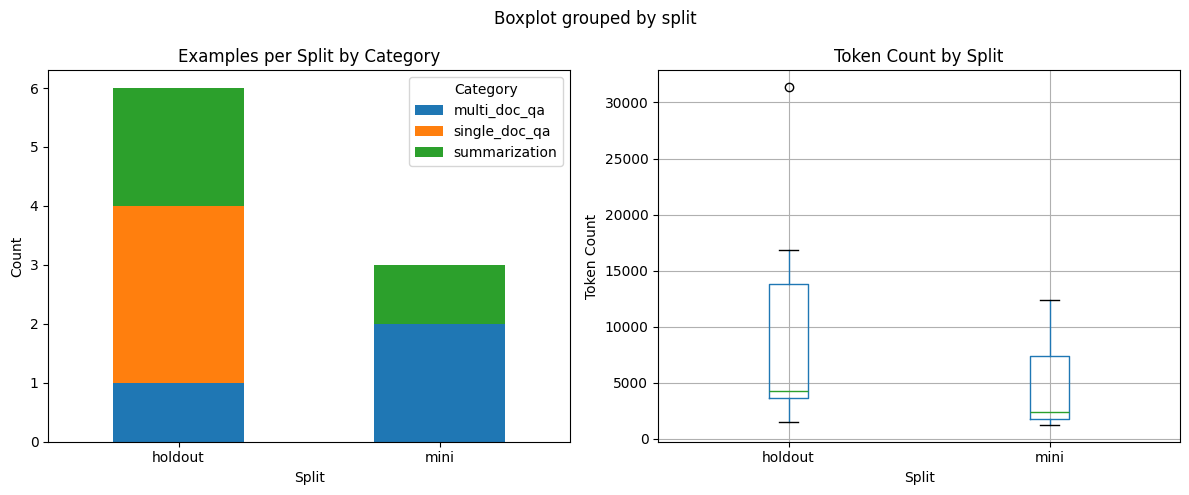

In [13]:
# Plot 3: Split distribution (mini vs holdout)
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Count by split and category
split_cat = df.groupby(["split", "category"]).size().unstack(fill_value=0)
split_cat.plot(kind="bar", stacked=True, ax=axes[0])
axes[0].set_title("Examples per Split by Category")
axes[0].set_xlabel("Split")
axes[0].set_ylabel("Count")
axes[0].legend(title="Category")
axes[0].tick_params(axis='x', rotation=0)

# Token count by split
df.boxplot(column="tokens", by="split", ax=axes[1])
axes[1].set_title("Token Count by Split")
axes[1].set_ylabel("Token Count")
axes[1].set_xlabel("Split")

plt.tight_layout()
plt.show()

## Schema Validation

Verify that the data conforms to the expected exp_sel_data_out.json schema.

In [14]:
# Schema validation
def validate_schema(data: dict) -> bool:
    """Validate data against exp_sel_data_out.json schema."""
    required_meta = ["source", "tokenizer", "description", "compression_budgets"]
    required_ds = ["dataset", "examples"]
    required_ex = [
        "input", "output",
        "metadata_task_name", "metadata_category", "metadata_task_id",
        "metadata_original_token_count",
        "metadata_compression_budget_2x", "metadata_compression_budget_4x", "metadata_compression_budget_8x",
        "metadata_split", "metadata_row_index"
    ]
    
    # Check metadata
    for key in required_meta:
        if key not in data["metadata"]:
            print(f"MISSING metadata field: {key}")
            return False
    
    # Check datasets
    for ds in data["datasets"]:
        for key in required_ds:
            if key not in ds:
                print(f"MISSING dataset field: {key}")
                return False
        
        for ex in ds["examples"]:
            for key in required_ex:
                if key not in ex:
                    print(f"MISSING example field: {key}")
                    return False
            
            # Type checks
            assert isinstance(ex["input"], str), "input must be string"
            assert isinstance(ex["output"], str), "output must be string"
            assert isinstance(ex["metadata_original_token_count"], int), "token count must be int"
            assert ex["metadata_original_token_count"] > 0, "token count must be positive"
            assert ex["metadata_split"] in ["mini", "holdout"], f"invalid split: {ex['metadata_split']}"
    
    print("✓ Schema validation PASSED")
    return True

validate_schema(data)

✓ Schema validation PASSED


True

## Summary

This notebook demonstrated the LongBench dataset prepared for prompt compression evaluation. Key points:

- **9 tasks** across 3 categories (single-doc QA, multi-doc QA, summarization)
- **LLaMA-3-8B tokenizer** used for token counting
- **Compression budgets** at 2x (50%), 4x (25%), 8x (12.5%) retention
- **Stratified splits**: mini (450 examples, 50/task) and holdout (1300 examples)
- **Schema**: exp_sel_data_out.json format with input, output, and metadata fields

The mini_demo_data.json contains a curated subset (1 example per task, 9 total) for quick prototyping. The full dataset contains 1750 examples and is available at the GitHub repository.